In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

import matplotlib.pyplot as plt
import seaborn as sns

from lime.lime_tabular import LimeTabularExplainer

import warnings
warnings.filterwarnings("ignore")

In [3]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("diabetes_data_upload.csv")

df.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [4]:
# ============================================================
# DATASET INFORMATION
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(520, 17)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null  

In [5]:
# ============================================================
# LABEL ENCODING
# ============================================================

le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,16,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,34,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,17,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,21,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,36,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [6]:
# ============================================================
# SPLIT FEATURES & TARGET
# ============================================================

X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (416, 16)
Test Shape: (104, 16)


In [7]:
# ============================================================
# INITIALIZE MODELS
# ============================================================

models = {

    "GaussianNB": GaussianNB(),

    "Linear SVC": SVC(
        kernel='linear',
        probability=True,
        random_state=42
    ),

    "Polynomial SVC": SVC(
        kernel='poly',
        degree=3,
        probability=True,
        random_state=42
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

models

{'GaussianNB': GaussianNB(),
 'Linear SVC': SVC(kernel='linear', probability=True, random_state=42),
 'Polynomial SVC': SVC(kernel='poly', probability=True, random_state=42),
 'MLP': MLPClassifier(max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(random_state=42)}


MODEL: GaussianNB

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93        40
           1       0.97      0.94      0.95        64

    accuracy                           0.94       104
   macro avg       0.94      0.94      0.94       104
weighted avg       0.94      0.94      0.94       104



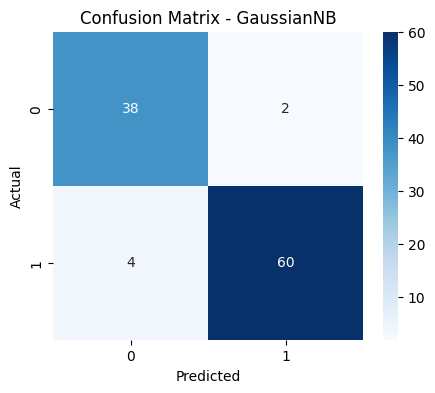


MODEL: Linear SVC

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92        40
           1       0.98      0.91      0.94        64

    accuracy                           0.93       104
   macro avg       0.92      0.94      0.93       104
weighted avg       0.94      0.93      0.93       104



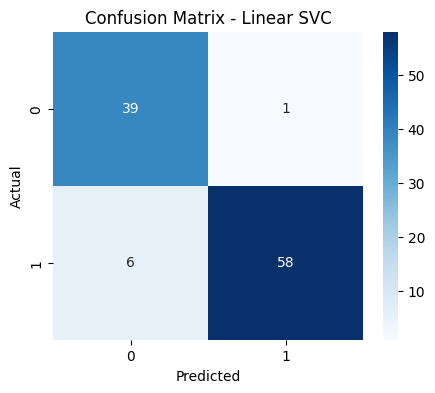


MODEL: Polynomial SVC

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.23      0.37        40
           1       0.67      1.00      0.81        64

    accuracy                           0.70       104
   macro avg       0.84      0.61      0.59       104
weighted avg       0.80      0.70      0.64       104



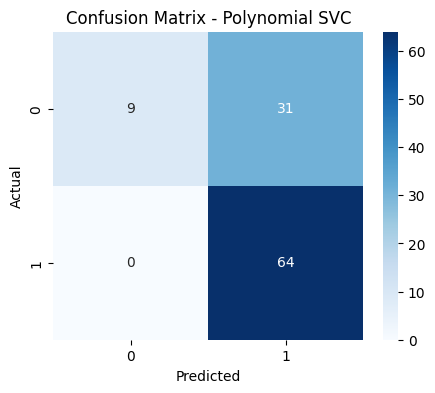


MODEL: MLP

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        40
           1       0.98      0.97      0.98        64

    accuracy                           0.97       104
   macro avg       0.97      0.97      0.97       104
weighted avg       0.97      0.97      0.97       104



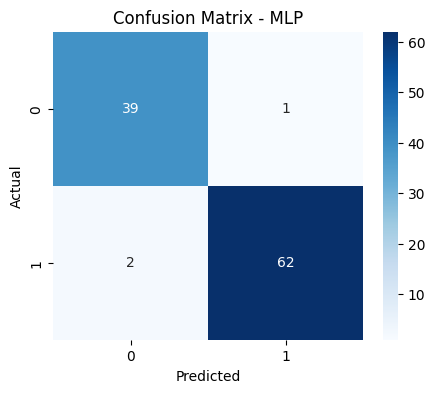


MODEL: Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        40
           1       1.00      0.98      0.99        64

    accuracy                           0.99       104
   macro avg       0.99      0.99      0.99       104
weighted avg       0.99      0.99      0.99       104



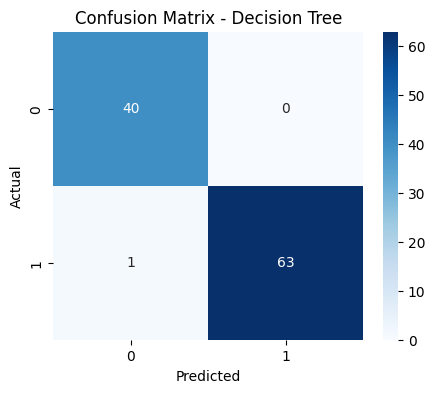

In [8]:
# ============================================================
# TRAIN & EVALUATE MODELS
# ============================================================

results = []

predictions_dict = {}

for name, model in models.items():

    print("\n================================================")
    print(f"MODEL: {name}")
    print("================================================")

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    predictions_dict[name] = y_pred

    # Evaluation Metrics
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, pre, rec, f1])

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [9]:
# ============================================================
# MODEL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,GaussianNB,0.942308,0.967742,0.937500,0.952381
1,Linear SVC,0.932692,0.983051,0.906250,0.943089
2,Polynomial SVC,0.701923,0.673684,1.000000,0.805031
3,MLP,0.971154,0.984127,0.968750,0.976378
4,Decision Tree,0.990385,1.000000,0.984375,0.992126


In [10]:
# ============================================================
# SORT BEST MODEL
# ============================================================

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
4,Decision Tree,0.990385,1.000000,0.984375,0.992126
3,MLP,0.971154,0.984127,0.968750,0.976378
0,GaussianNB,0.942308,0.967742,0.937500,0.952381
1,Linear SVC,0.932692,0.983051,0.906250,0.943089
2,Polynomial SVC,0.701923,0.673684,1.000000,0.805031


In [11]:
# ============================================================
# MAJORITY VOTING
# ============================================================

all_predictions = np.array(list(predictions_dict.values()))

# Transpose prediction matrix
all_predictions = all_predictions.T

final_predictions = []

for row in all_predictions:

    counts = np.bincount(row)

    final_class = np.argmax(counts)

    final_predictions.append(final_class)

final_predictions = np.array(final_predictions)

print(final_predictions[:10])

[0 1 1 0 0 1 1 0 1 0]


In [12]:
# ============================================================
# MISCLASSIFIED INSTANCES
# ============================================================

actual = y_test.values

misclassified_indices = np.where(
    final_predictions != actual
)[0]

print("Misclassified Instances:")
print(misclassified_indices)

Misclassified Instances:
[69 91]


In [13]:
# ============================================================
# DISPLAY MISCLASSIFIED INSTANCES
# ============================================================

misclassified_samples = X_test.iloc[misclassified_indices]

misclassified_samples

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity
1,34,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0
321,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [14]:
# ============================================================
# INITIALIZE LIME
# ============================================================

explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns.tolist(),
    class_names=["Negative", "Positive"],
    mode='classification'
)


LIME Explanation for Instance: 69


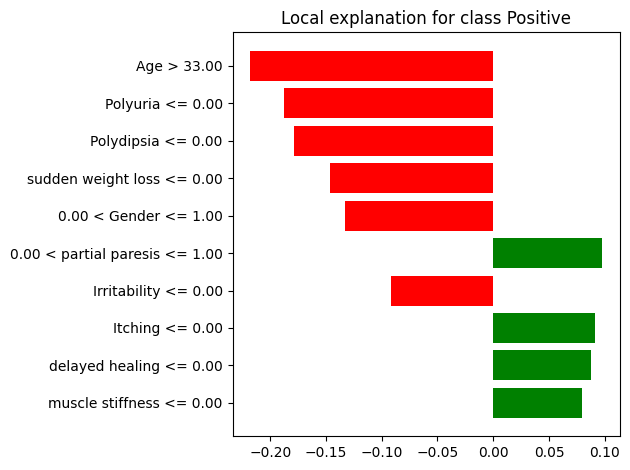


LIME Explanation for Instance: 91


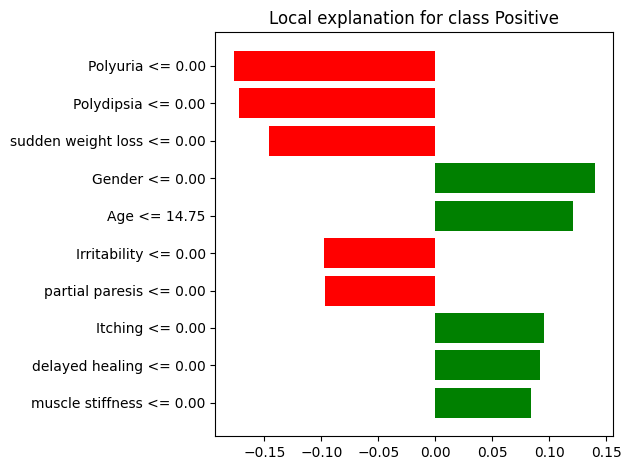

In [15]:
# ============================================================
# LIME EXPLANATION
# ============================================================

# Use Polynomial SVC
model = models["Polynomial SVC"]

for idx in misclassified_indices[:4]:

    print("\n========================================")
    print(f"LIME Explanation for Instance: {idx}")
    print("========================================")

    exp = explainer.explain_instance(
        X_test.iloc[idx].values,
        model.predict_proba,
        num_features=10
    )

    fig = exp.as_pyplot_figure()

    plt.tight_layout()
    plt.show()

In [16]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

dt_model = models["Decision Tree"]

importance = dt_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
2,Polyuria,0.415571
1,Gender,0.116148
0,Age,0.084869
14,Alopecia,0.082554
3,Polydipsia,0.080417
11,delayed healing,0.053807
13,muscle stiffness,0.049222
7,Genital thrush,0.028853
15,Obesity,0.028486
4,sudden weight loss,0.025888


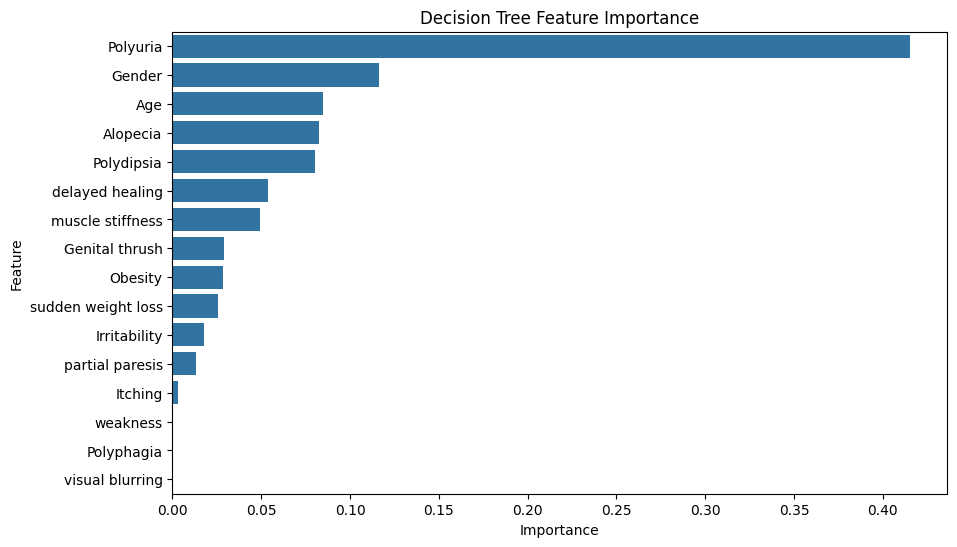

In [17]:
# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df
)

plt.title("Decision Tree Feature Importance")

plt.show()

In [18]:
# ============================================================
# FINAL SUMMARY
# ============================================================

best_model = results_df.iloc[0]

print("========================================")
print("FINAL SUMMARY")
print("========================================")

print(f"Best Model: {best_model['Model']}")
print(f"Accuracy : {best_model['Accuracy']:.4f}")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"Recall   : {best_model['Recall']:.4f}")
print(f"F1-Score : {best_model['F1-Score']:.4f}")

FINAL SUMMARY
Best Model: Decision Tree
Accuracy : 0.9904
Precision: 1.0000
Recall   : 0.9844
F1-Score : 0.9921
